# 树叶分类

In [26]:
import pandas as pd

# 1. 查看训练集信息
train_df = pd.read_csv('../data/leaves/train.csv')
print("训练集信息：")
print(f"  - 样本数: {len(train_df)}")
print(f"  - 列: {train_df.columns.tolist()}")
print(f"\n类别数: {train_df['label'].nunique()}")

# 2. 查看测试集信息
test_df = pd.read_csv('../data/leaves/test.csv')
print("测试集信息：")
print(f"  - 样本数: {len(test_df)}")
print(f"  - 列: {test_df.columns.tolist()}")

# 3. 查看submission格式
submission_df = pd.read_csv('../data/leaves/sample_submission.csv')
print(f"\n提交格式示例：")
print(submission_df.head())

# 4. 检查图片目录
import os
img_dir = '../data/leaves/images'
img_files = os.listdir(img_dir)
print(f"\n图片总数: {len(img_files)}")
print(f"前3张图片: {img_files[:3]}")

训练集信息：
  - 样本数: 18353
  - 列: ['image', 'label']

类别数: 176
测试集信息：
  - 样本数: 8800
  - 列: ['image']

提交格式示例：
              image                   label
0  images/18353.jpg      halesia_tetraptera
1  images/18354.jpg   robinia_pseudo-acacia
2  images/18355.jpg  chionanthus_virginicus
3  images/18356.jpg         ulmus_americana
4  images/18357.jpg           picea_pungens

图片总数: 27153
前3张图片: ['1309.jpg', '13090.jpg', '13091.jpg']


In [27]:
from PIL import Image
import os

img_dir = '../data/leaves/images'
sample_imgs = os.listdir(img_dir)[:5]

for img_name in sample_imgs:
    img = Image.open(os.path.join(img_dir, img_name))
    print(f"{img_name}: {img.size}")  # 输出 (宽, 高)

1309.jpg: (224, 224)
13090.jpg: (224, 224)
13091.jpg: (224, 224)
13092.jpg: (224, 224)
1000.jpg: (224, 224)


In [28]:
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

class LeafDataset(Dataset):
    def __init__(self, csv_file, img_dir, transform=None):
        self.df = pd.read_csv(csv_file)
        self.img_dir = img_dir
        # transform 是“预处理/增广流水线”，可以为 None
        self.transform = transform
        
        # 读取标签并建立“类别名 -> 数字ID”的映射（CrossEntropyLoss 需要数字标签）
        self.classes = sorted(self.df['label'].unique())
        self.label_to_idx = {label: idx for idx, label in enumerate(self.classes)}

    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_name = row['image']
        label = row['label']
        label_idx = self.label_to_idx[label]

        img_path = os.path.join(self.img_dir, img_name)

        # convert('RGB')：强制把图像转成3通道RGB
        # 作用：
        # 1) 防止有些图是灰度/带Alpha通道，导致通道数不一致报错
        # 2) 与预训练ImageNet模型输入格式一致（3通道）
        img = Image.open(img_path).convert('RGB')

        # 如果设置了transform，就执行“增广+张量化+标准化”
        if self.transform:
            img = self.transform(img)

        return img, label_idx

# ===== 数据增广开关（训练可选项） =====
# True  -> 使用随机数据增广（泛化更强，训练更慢）
# False -> 不使用随机增广（训练更快，通常更易过拟合）
USE_AUGMENTATION = True

# 训练集：强增广版本
train_transform_aug = transforms.Compose([
    # 随机裁剪并缩放到224x224，scale控制裁剪面积占原图比例，ratio控制宽高比
    transforms.RandomResizedCrop(224, scale=(0.6, 1.0), ratio=(0.75, 1.33)),
    # 50%概率水平翻转，提升方向鲁棒性
    transforms.RandomHorizontalFlip(p=0.5),
    # 随机旋转，提升角度鲁棒性
    transforms.RandomRotation(20),
    # 亮度/对比度/饱和度/色调扰动，提升光照与颜色鲁棒性
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    # RandAugment：自动选择两种增强操作（强增广，常用于竞赛提升泛化），暂时不使用
    # transforms.RandAugment(num_ops=2, magnitude=7),

    # 把PIL图像变成Tensor，像素范围从[0,255]缩放到[0,1]，不使用
    transforms.ToTensor(),
    # Normalize：按ImageNet统计量做标准化
    # 公式：x' = (x - mean) / std
    # 目的：让各通道分布更稳定，配合预训练权重通常收敛更快、效果更好
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    # 随机擦除一块区域，模拟遮挡，降低过拟合，看起来不需要使用
    # transforms.RandomErasing(p=0.25, scale=(0.02, 0.20), ratio=(0.3, 3.3), value='random')
])

# 训练集：无随机增广版本（仅基础预处理）
train_transform_plain = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 验证/测试：始终不做随机增广，保证评估稳定
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 根据开关选择训练transform
train_transform = train_transform_aug if USE_AUGMENTATION else train_transform_plain

train_dataset = LeafDataset(
    csv_file='../data/leaves/train.csv',
    img_dir='../data/leaves',
    transform=train_transform
)

print(f"数据集大小: {len(train_dataset)}")
print(f"类别数: {len(train_dataset.classes)}")
print(f"数据增广开关 USE_AUGMENTATION = {USE_AUGMENTATION}")

数据集大小: 18353
类别数: 176
数据增广开关 USE_AUGMENTATION = True


In [29]:
from torch.utils.data import DataLoader, Subset
import torch

# 1) 划分比例：90%训练，10%验证
train_size = int(0.9 * len(train_df))
val_size = len(train_df) - train_size

# 2) 固定随机种子并划分索引
# 为什么要固定随机种子？
# - 可复现：你今天跑和明天跑，训练/验证划分一致，便于公平对比实验
# - 调参可靠：只改变“一个变量”（如学习率、增广强度）时，结果差异更可信
generator = torch.Generator().manual_seed(42)
all_indices = torch.randperm(len(train_df), generator=generator).tolist()
train_indices = all_indices[:train_size]
val_indices = all_indices[train_size:]

# 3) 训练/验证分别使用不同transform
# - 训练集使用 train_transform（由 USE_AUGMENTATION 控制：增强版或基础版）
# - 验证集固定使用 val_transform（不做随机增广，评估更稳定）
train_dataset_selected = LeafDataset(
    csv_file='../data/leaves/train.csv',
    img_dir='../data/leaves',
    transform=train_transform
)
val_dataset_plain = LeafDataset(
    csv_file='../data/leaves/train.csv',
    img_dir='../data/leaves',
    transform=val_transform
)

train_set = Subset(train_dataset_selected, train_indices)
val_set = Subset(val_dataset_plain, val_indices)

# 4) DataLoader
# - train_loader: shuffle=True 打乱样本顺序，提升训练稳定性
# - val_loader: shuffle=False 保持评估一致性
train_loader = DataLoader(train_set, batch_size=32, shuffle=True, num_workers=0)
val_loader = DataLoader(val_set, batch_size=32, shuffle=False, num_workers=0)

print(f"训练集: {len(train_set)}")
print(f"验证集: {len(val_set)}")
print(f"当前训练模式: {'增强数据集' if USE_AUGMENTATION else '基础数据集(无随机增广)'}")
print('验证集始终使用 Resize+Normalize（稳定评估）')

训练集: 16517
验证集: 1836
当前训练模式: 增强数据集
验证集始终使用 Resize+Normalize（稳定评估）


In [30]:
import torch
import torch.nn as nn
from torchvision import models

# 1. 选择设备
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("使用设备:", device)

# 2. 加载预训练ResNet50
model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

# 3. 修改最后一层输出为176类
num_classes = 176
model.fc = nn.Linear(model.fc.in_features, num_classes)

model = model.to(device)

print(model)

使用设备: cuda
ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), 

In [31]:
import torch.optim as optim

# 训练配置（先运行这个单元）
criterion = nn.CrossEntropyLoss()

# 学习率先降一点，训练更稳
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)

# 按epoch平滑衰减学习率
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30, eta_min=1e-6)

print('criterion / optimizer / scheduler 已定义')
print('初始学习率:', optimizer.param_groups[0]['lr'])

criterion / optimizer / scheduler 已定义
初始学习率: 0.0001


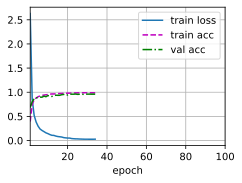

epoch 34: loss 0.0278, train acc 0.9886, val acc 0.9602, lr 5.28e-06
best val acc: 0.9630 (epoch 24), early-stop wait: 10/10

触发早停：连续 10 个epoch无提升，停止训练。

已加载最佳模型：./best_leaf_model.pth，best val acc=0.9630，来自epoch 24


C:\Users\fangheng\AppData\Local\Temp\ipykernel_7172\1476621266.py:81: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_ckpt_path, map_loca

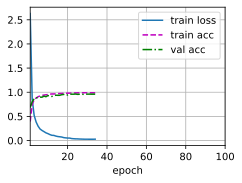

In [32]:
from d2l import torch as d2l
import matplotlib.pyplot as plt
from IPython import display
import copy


def evaluate_accuracy(model, data_loader, device):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for X, y in data_loader:
            X, y = X.to(device), y.to(device)
            preds = model(X).argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.numel()
    return correct / total


num_epochs = 100
patience = 10                 # 早停容忍轮数：连续5轮不提升就停止
min_delta = 1e-4             # 认为“有提升”的最小幅度
best_val_acc = 0.0
best_epoch = 0
wait = 0
best_ckpt_path = './best_leaf_model.pth'

animator = d2l.Animator(xlabel='epoch', xlim=[1, num_epochs],
                        legend=['train loss', 'train acc', 'val acc'])

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    running_correct = 0
    total = 0

    for X, y in train_loader:
        X, y = X.to(device), y.to(device)

        outputs = model(X)
        loss = criterion(outputs, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * y.size(0)
        running_correct += (outputs.argmax(dim=1) == y).sum().item()
        total += y.numel()

    train_loss = running_loss / total
    train_acc = running_correct / total
    val_acc = evaluate_accuracy(model, val_loader, device)

    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']

    # best checkpoint：只要验证集提升就保存
    if val_acc > best_val_acc + min_delta:
        best_val_acc = val_acc
        best_epoch = epoch + 1
        wait = 0
        torch.save(model.state_dict(), best_ckpt_path)
    else:
        wait += 1

    animator.add(epoch + 1, (train_loss, train_acc, val_acc))

    display.clear_output(wait=True) # 每轮结束后清除之前的输出，保持界面整洁
    display.display(plt.gcf()) # 显示当前图表

    print(f"epoch {epoch + 1:02d}: loss {train_loss:.4f}, train acc {train_acc:.4f}, val acc {val_acc:.4f}, lr {current_lr:.2e}")
    print(f"best val acc: {best_val_acc:.4f} (epoch {best_epoch}), early-stop wait: {wait}/{patience}")

    # early stopping
    if wait >= patience:
        print(f"\n触发早停：连续 {patience} 个epoch无提升，停止训练。")
        break

# 训练结束后恢复到最佳权重（后续预测直接用最优模型）
model.load_state_dict(torch.load(best_ckpt_path, map_location=device))
print(f"\n已加载最佳模型：{best_ckpt_path}，best val acc={best_val_acc:.4f}，来自epoch {best_epoch}")

In [33]:
# 第9步：模型保存和测试集预测
import os

# 训练后权重另存一份（此时一般已是best权重，因为上个单元最后已load best）
torch.save(model.state_dict(), './leaf_model_last_loaded.pth')
print("✓ 当前模型已保存到 leaf_model_last_loaded.pth")

# 如果存在best checkpoint，优先加载它用于提交
best_ckpt_path = './best_leaf_model.pth'
if os.path.exists(best_ckpt_path):
    model.load_state_dict(torch.load(best_ckpt_path, map_location=device))
    print(f"✓ 已加载best checkpoint: {best_ckpt_path}")
else:
    print("⚠ 未找到best checkpoint，使用当前内存中的模型参数进行预测")

# 在测试集上进行预测
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])
])

class TestLeafDataset(Dataset):
    """测试集数据类（没有标签）"""
    def __init__(self, csv_file, img_dir, transform=None):
        self.df = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_name = row['image']

        img_path = os.path.join(self.img_dir, img_name)
        img = Image.open(img_path).convert('RGB')

        if self.transform:
            img = self.transform(img)

        return img, img_name

# 创建测试集
test_dataset = TestLeafDataset(
    csv_file='../data/leaves/test.csv',
    img_dir='../data/leaves',
    transform=test_transform
)

test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)
print(f"✓ 测试集加载完成: {len(test_dataset)} 张图片")

# 在测试集上预测
model.eval()
predictions = []
image_names = []

with torch.no_grad():
    for images, names in test_loader:
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1)

        predictions.extend(preds.cpu().numpy())
        image_names.extend(names)

print(f"✓ 预测完成，共 {len(predictions)} 个样本")

# 将预测结果映射回类别标签名
idx_to_label = {v: k for k, v in train_dataset.label_to_idx.items()}
predicted_labels = [idx_to_label[idx] for idx in predictions]

# 生成提交文件
submission = pd.DataFrame({
    'image': image_names,
    'label': predicted_labels
})

submission.to_csv('submission.csv', index=False)
print("✓ 提交文件已保存到 submission.csv")
print("\n前5行预测结果：")
print(submission.head())

✓ 当前模型已保存到 leaf_model_last_loaded.pth
✓ 已加载best checkpoint: ./best_leaf_model.pth
✓ 测试集加载完成: 8800 张图片


C:\Users\fangheng\AppData\Local\Temp\ipykernel_7172\1478754746.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_ckpt_path, map_loca

✓ 预测完成，共 8800 个样本
✓ 提交文件已保存到 submission.csv

前5行预测结果：
              image                label
0  images/18353.jpg      asimina_triloba
1  images/18354.jpg         betula_nigra
2  images/18355.jpg  platanus_acerifolia
3  images/18356.jpg       pinus_bungeana
4  images/18357.jpg  platanus_acerifolia


1. 使用resnet18预训练模型，10 epochs，batch_size=64，学习率0.001，Adam优化器，准确率93.99%
2. 使用resnet50预训练模型，30 epochs，batch_size=64，学习率0.001，Adam优化器，准确率96.68%
3. 使用resnet50预训练模型，30 epochs, batch_size=64，学习率0.001，Adam优化器，强数据增广，准确率95.81%
4. 使用resnet50预训练模型，24 epochs, batch_size=64，学习率0.001，Adam优化器，调整优化数据增广，准确率96.02%